### Experimental Setup

In [ ]:
FEATURE_SELECTION_METHOD = "WOA"
DEEP_LEARNING_CATEGORY = "Classical"
MODEL_ARCHITECTURE = "MCDCNN"
DATASET_NAME = "Opensnoop"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [ ]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Load QUT-DV25 Dataset


In [ ]:
# ============================================================
# Data Loading and Initial Inspection
# ================== ==========================================

# Define the datasetfile path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Total_Paths,Total_Error,Total_ File_Descriptor,Python_Related_Keywords,Install_Package_Keywords,Root_DIR_Installation,Temporary_DIR_Installation,Home_DIR_Installation,User_Access,Sys_Access,Etc_DIR_Installation,Other_DIR_Installation,Level
0,10Cent10-999.0.4.tar.gz,8045,8045,29,1083,2305,0,71,792,411,1225,151,5395,1
1,10Cent11-999.0.4.tar.gz,4790,4790,12,1616,843,2,87,1118,721,1200,104,1558,1
2,11Cent-999.0.0.tar.gz,26159,26159,27,3299,4536,0,200,2485,1072,1236,450,20716,1
3,11Cent-999.0.1.tar.gz,11194,11194,28,1521,2558,2,97,1035,891,1211,265,7693,1
4,11Cent-999.0.2.tar.gz,13561,13561,35,2656,5265,501,17,1497,1719,1219,291,8317,1


### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()



### Selected Features

In [ ]:
selected_features = ['Total_Paths', 'Total_ File_Descriptor', 'Python_Related_Keywords', 'Root_DIR_Installation', 'Temporary_DIR_Installation', 'User_Access', 'Sys_Access', 'Other_DIR_Installation']


### Data Preprocessing

In [ ]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

### Setup OUTPUT_DIR

In [ ]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)


#Model

In [ ]:
# ============================================================
# Define model saving configuration
# ============================================================

MODEL_NAME = "best_model.h5"


# ==========================
# Detect categorical & numeric columns
# ==========================
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()


# ==========================
# Scale numeric features
# ==========================
if len(numeric_cols) > 0:
    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num   = scaler.transform(X_val[numeric_cols])
    X_test_num  = scaler.transform(X_test[numeric_cols])
else:
    X_train_num = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_num   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_num  = np.empty((len(X_test), 0), dtype=np.float32)


# ==========================
# Apply TF-IDF separately per categorical column
# ==========================
processed_texts_train = []
processed_texts_val = []
processed_texts_test = []

tfidf_vectorizers = {}

for col in categorical_cols:
    tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=500)
    tfidf.fit(X_train[col].astype(str))
    tfidf_vectorizers[col] = tfidf

    processed_texts_train.append(tfidf.transform(X_train[col].astype(str)).toarray())
    processed_texts_val.append(tfidf.transform(X_val[col].astype(str)).toarray())
    processed_texts_test.append(tfidf.transform(X_test[col].astype(str)).toarray())

if len(processed_texts_train) > 0:
    X_train_text = np.concatenate(processed_texts_train, axis=1).astype(np.float32)
    X_val_text   = np.concatenate(processed_texts_val, axis=1).astype(np.float32)
    X_test_text  = np.concatenate(processed_texts_test, axis=1).astype(np.float32)
else:
    X_train_text = np.empty((len(X_train), 0), dtype=np.float32)
    X_val_text   = np.empty((len(X_val), 0), dtype=np.float32)
    X_test_text  = np.empty((len(X_test), 0), dtype=np.float32)


# ==========================
# Concatenate numeric + text features
# ==========================
X_train_processed = np.hstack([X_train_num, X_train_text]).astype(np.float32)
X_val_processed   = np.hstack([X_val_num, X_val_text]).astype(np.float32)
X_test_processed  = np.hstack([X_test_num, X_test_text]).astype(np.float32)


# ==========================
# Convert to float32 and reshape
# ==========================
X_train_dense = X_train_processed.reshape((X_train_processed.shape[0], X_train_processed.shape[1], 1))
X_val_dense   = X_val_processed.reshape((X_val_processed.shape[0], X_val_processed.shape[1], 1))
X_test_dense  = X_test_processed.reshape((X_test_processed.shape[0], X_test_processed.shape[1], 1))


# ==========================
# Ensure labels are numeric
# ==========================
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)


# ==========================
# Callbacks
# ==========================
checkpoint_cb = ModelCheckpoint(MODEL_NAME, monitor="val_accuracy", save_best_only=True, mode="max", verbose=1)
reduce_lr_cb  = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=200, verbose=1)
early_stop_cb = EarlyStopping(monitor="val_accuracy", patience=200, restore_best_weights=True)


# ==========================
# Build MCDCNN Model
# ==========================

# Define input dimensions
n_timesteps = X_train_dense.shape[1]
n_channels  = X_train_dense.shape[2]

# Configure padding based on sequence length
padding_type = "same" if n_timesteps < 60 else "valid"

# Define multi-channel input branches
inputs = []
branch_outputs = []

for i in range(n_channels):
    # Input for each channel
    input_i = keras.layers.Input(
        shape=(n_timesteps, 1),
        name=f"input_channel_{i+1}"
    )
    inputs.append(input_i)

    # Convolutional Block 1
    x = keras.layers.Conv1D(
        filters=8,
        kernel_size=5,
        activation="relu",
        padding=padding_type,
        name=f"conv1_channel_{i+1}"
    )(input_i)

    x = keras.layers.MaxPooling1D(
        pool_size=2,
        name=f"maxpool1_channel_{i+1}"
    )(x)

    # Convolutional Block 2
    x = keras.layers.Conv1D(
        filters=8,
        kernel_size=5,
        activation="relu",
        padding=padding_type,
        name=f"conv2_channel_{i+1}"
    )(x)

    x = keras.layers.MaxPooling1D(
        pool_size=2,
        name=f"maxpool2_channel_{i+1}"
    )(x)

    # Flatten Features
    x = keras.layers.Flatten(name=f"flatten_channel_{i+1}")(x)

    branch_outputs.append(x)

# Feature Fusion (Concatenation)
if n_channels == 1:
    x = branch_outputs[0]
else:
    x = keras.layers.Concatenate(name="feature_fusion")(branch_outputs)

# Fully Connected Layer
x = keras.layers.Dense(
    units=732,
    activation="relu",
    name="fc1"
)(x)

# Output Layer
outputs = keras.layers.Dense(
    units=1,
    activation="sigmoid",
    name="output_layer"
)(x)

# Build Model
model = keras.models.Model(
    inputs=inputs,
    outputs=outputs,
    name="MCDCNN"
)


# ==========================
# Compile Model
# ==========================

model.compile(
    tf.keras.optimizers.legacy.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)




### Compime the Model

In [ ]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, early_stop_cb],
    verbose=2
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200

Epoch 1: val_accuracy improved from -inf to 0.84540, saving model to best_model.h5
2498/2498 - 18s - loss: 0.4426 - accuracy: 0.7938 - val_loss: 0.3637 - val_accuracy: 0.8454 - 18s/epoch - 7ms/step
Epoch 2/200

Epoch 2: val_accuracy improved from 0.84540 to 0.84960, saving model to best_model.h5
2498/2498 - 11s - loss: 0.3568 - accuracy: 0.8392 - val_loss: 0.3447 - val_accuracy: 0.8496 - 11s/epoch - 4ms/step
Epoch 3/200

Epoch 3: val_accuracy improved from 0.84960 to 0.85661, saving model to best_model.h5
2498/2498 - 11s - loss: 0.3347 - accuracy: 0.8507 - val_loss: 0.3284 - val_accuracy: 0.8566 - 11s/epoch - 4ms/step
Epoch 4/200

Epoch 4: val_accuracy improved from 0.85661 to 0.85708, saving model to best_model.h5
2498/2498 - 11s - loss: 0.3263 - accuracy: 0.8528 - val_loss: 0.3125 - val_accuracy: 0.8571 - 11s/epoch - 4ms/step
Epoch 5/200

Epoch 5: val_accuracy improved from 0.85708 to 0.86268, saving model to best_model.h5
2498/2498 - 11s - loss: 0.3170 - accuracy: 0.858

Epoch 44/200

Epoch 44: val_accuracy improved from 0.88136 to 0.88977, saving model to best_model.h5
2498/2498 - 10s - loss: 0.2334 - accuracy: 0.8949 - val_loss: 0.2866 - val_accuracy: 0.8898 - 10s/epoch - 4ms/step
Epoch 45/200

Epoch 45: val_accuracy did not improve from 0.88977
2498/2498 - 10s - loss: 0.2330 - accuracy: 0.8958 - val_loss: 0.3048 - val_accuracy: 0.8664 - 10s/epoch - 4ms/step
Epoch 46/200

Epoch 46: val_accuracy did not improve from 0.88977
2498/2498 - 10s - loss: 0.2338 - accuracy: 0.8982 - val_loss: 0.2830 - val_accuracy: 0.8888 - 10s/epoch - 4ms/step
Epoch 47/200

Epoch 47: val_accuracy did not improve from 0.88977
2498/2498 - 10s - loss: 0.2326 - accuracy: 0.8998 - val_loss: 0.2962 - val_accuracy: 0.8730 - 10s/epoch - 4ms/step
Epoch 48/200

Epoch 48: val_accuracy did not improve from 0.88977
2498/2498 - 10s - loss: 0.2273 - accuracy: 0.9009 - val_loss: 0.3093 - val_accuracy: 0.8697 - 10s/epoch - 4ms/step
Epoch 49/200

Epoch 49: val_accuracy did not improve from 0.

Epoch 89/200

Epoch 89: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1939 - accuracy: 0.9149 - val_loss: 0.3153 - val_accuracy: 0.8762 - 10s/epoch - 4ms/step
Epoch 90/200

Epoch 90: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1882 - accuracy: 0.9199 - val_loss: 0.3049 - val_accuracy: 0.8781 - 10s/epoch - 4ms/step
Epoch 91/200

Epoch 91: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1860 - accuracy: 0.9167 - val_loss: 0.3313 - val_accuracy: 0.8772 - 9s/epoch - 4ms/step
Epoch 92/200

Epoch 92: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1880 - accuracy: 0.9149 - val_loss: 0.3145 - val_accuracy: 0.8818 - 9s/epoch - 4ms/step
Epoch 93/200

Epoch 93: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1885 - accuracy: 0.9159 - val_loss: 0.3007 - val_accuracy: 0.8818 - 9s/epoch - 4ms/step
Epoch 94/200

Epoch 94: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1832 - ac


Epoch 134: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1677 - accuracy: 0.9258 - val_loss: 0.3759 - val_accuracy: 0.8786 - 9s/epoch - 4ms/step
Epoch 135/200

Epoch 135: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1618 - accuracy: 0.9299 - val_loss: 0.3603 - val_accuracy: 0.8912 - 9s/epoch - 4ms/step
Epoch 136/200

Epoch 136: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1610 - accuracy: 0.9284 - val_loss: 0.3572 - val_accuracy: 0.8851 - 9s/epoch - 4ms/step
Epoch 137/200

Epoch 137: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1602 - accuracy: 0.9277 - val_loss: 0.3894 - val_accuracy: 0.8800 - 9s/epoch - 4ms/step
Epoch 138/200

Epoch 138: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1623 - accuracy: 0.9286 - val_loss: 0.3507 - val_accuracy: 0.8940 - 10s/epoch - 4ms/step
Epoch 139/200

Epoch 139: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1605 - accura

2498/2498 - 9s - loss: 0.1455 - accuracy: 0.9360 - val_loss: 0.4321 - val_accuracy: 0.8837 - 9s/epoch - 4ms/step
Epoch 180/200

Epoch 180: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1486 - accuracy: 0.9369 - val_loss: 0.4231 - val_accuracy: 0.8870 - 9s/epoch - 4ms/step
Epoch 181/200

Epoch 181: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1417 - accuracy: 0.9352 - val_loss: 0.4124 - val_accuracy: 0.8879 - 10s/epoch - 4ms/step
Epoch 182/200

Epoch 182: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1466 - accuracy: 0.9352 - val_loss: 0.4490 - val_accuracy: 0.8846 - 10s/epoch - 4ms/step
Epoch 183/200

Epoch 183: val_accuracy did not improve from 0.89584
2498/2498 - 10s - loss: 0.1402 - accuracy: 0.9389 - val_loss: 0.4556 - val_accuracy: 0.8874 - 10s/epoch - 4ms/step
Epoch 184/200

Epoch 184: val_accuracy did not improve from 0.89584
2498/2498 - 9s - loss: 0.1467 - accuracy: 0.9384 - val_loss: 0.4057 - val_accuracy: 0.888

### Clear Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [ ]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()

val_loss, val_acc = model.evaluate(X_val_dense, y_val, verbose=0)

end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()

test_loss, test_acc = model.evaluate(X_test_dense, y_test, verbose=0)

end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")



Training Time: 1931.86 seconds
Validation Time: 0.23 seconds
Testing Time: 0.17 seconds


### Trainig and Validation Plot

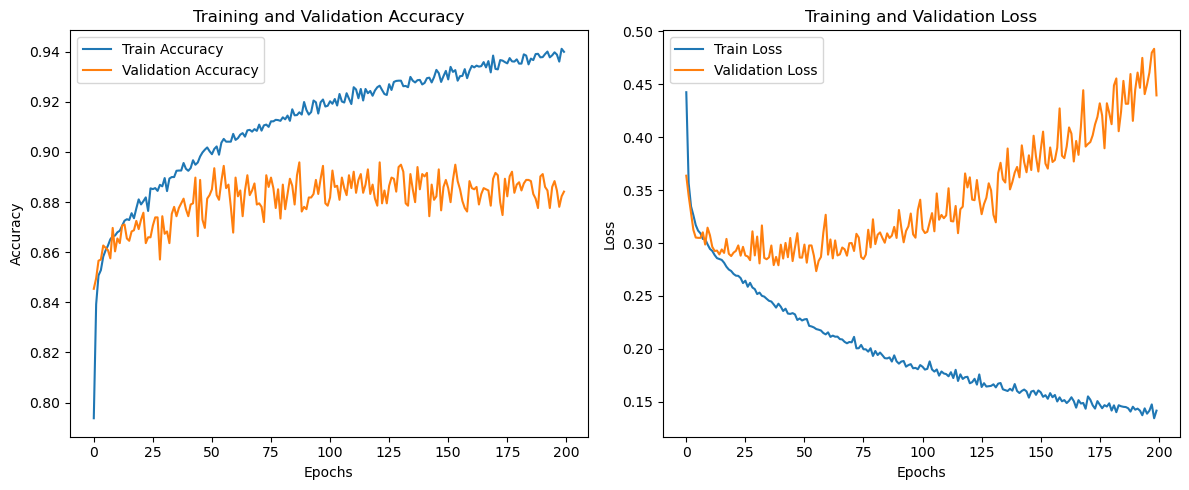

In [ ]:
# === Plot Accuracy and Loss ===
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.tight_layout()
plt.show()

### Classification Report

313/313 [==============================] - 0s 1ms/step

=== Classification Report (Train) ===
              precision    recall  f1-score   support

         0.0   0.924819  0.971800  0.947728      5000
         1.0   0.970222  0.920826  0.944879      4989

    accuracy                       0.946341      9989
   macro avg   0.947520  0.946313  0.946303      9989
weighted avg   0.947495  0.946341  0.946305      9989


=== Confusion Matrix (Train) ===


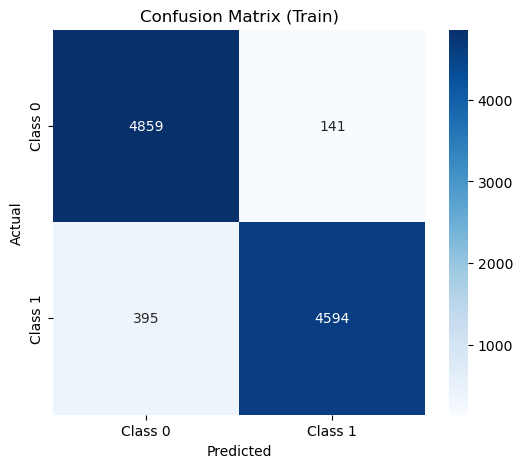

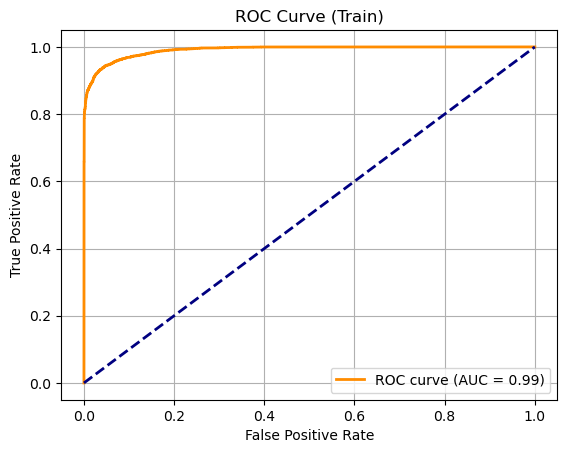

67/67 [==============================] - 0s 1ms/step

=== Classification Report (Validation) ===
              precision    recall  f1-score   support

         0.0   0.865897  0.909515  0.887170      1072
         1.0   0.904433  0.858746  0.880998      1069

    accuracy                       0.884166      2141
   macro avg   0.885165  0.884131  0.884084      2141
weighted avg   0.885138  0.884166  0.884088      2141


=== Confusion Matrix (Validation) ===


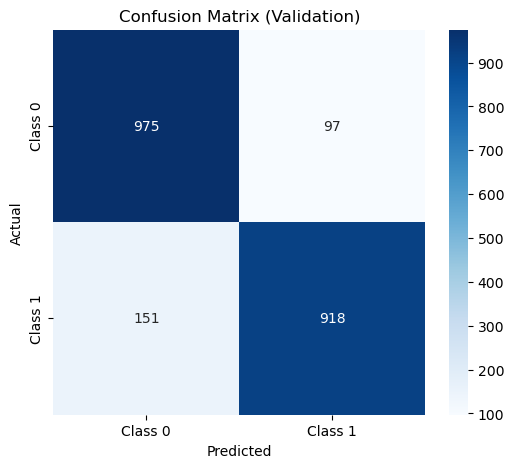

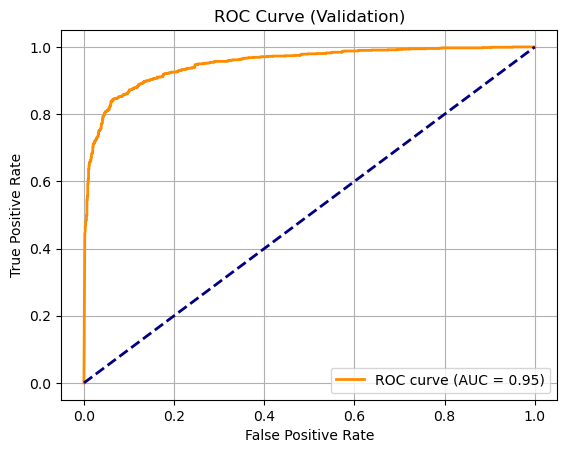

67/67 [==============================] - 0s 1ms/step

=== Classification Report (Test) ===
              precision    recall  f1-score   support

         0.0   0.856769  0.915112  0.884980      1072
         1.0   0.908635  0.846586  0.876513      1069

    accuracy                       0.880897      2141
   macro avg   0.882702  0.880849  0.880747      2141
weighted avg   0.882665  0.880897  0.880752      2141


=== Confusion Matrix (Test) ===


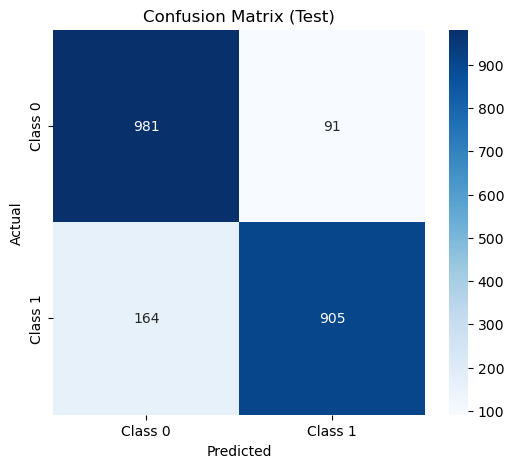

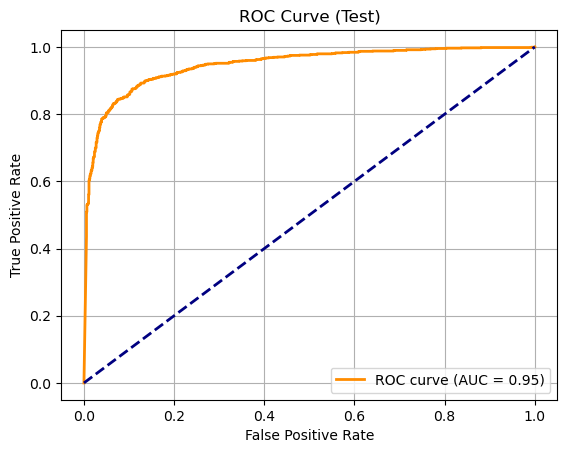

In [ ]:


# Helper function to generate evaluation metrics
def evaluate_and_plot(model, X, y, dataset_name):
    y_prob = model.predict(X).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # Classification report
    print(f"\n=== Classification Report ({dataset_name}) ===")
    print(classification_report(y, y_pred,digits=6))

    # Confusion matrix
    print(f"\n=== Confusion Matrix ({dataset_name}) ===")
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve ({dataset_name})')
    plt.legend(loc="lower right")
    plt.grid()
    plt.show()


# === Evaluate on Train, Validation, and Test ===
evaluate_and_plot(model, X_train_dense, y_train, "Train")
evaluate_and_plot(model, X_val_dense, y_val, "Validation")
evaluate_and_plot(model, X_test_dense, y_test, "Test")

### Clear Final Backend Session

In [ ]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()